# Distance Bias and Composite Motif Detection

This tutorial covers detecting and analyzing fixed-distance binding patterns:
- Detecting patterns with fixed-distance binding bias using {func}`~tfmindi.tl.detect_distance_bias`
- Visualizing distance bias with profile and heatmap plots
- Extending seqlets to capture composite motifs using {func}`~tfmindi.tl.extend_biased_seqlets`
- Re-clustering extended seqlets to identify dimers and multimers

In [3]:
import tfmindi as tm

%matplotlib inline

DATA_DIR = "../../../../data/tfmindi/"  # change to your project's data directory

In [4]:
# Load clustered data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

## What is distance bias?

Distance bias occurs when transcription factor binding sites show a preference to occur at fixed distances from each other. 
For example, the SOX10-TF has a commonly occuring dimer motif that binds cooperatively, yet, seqlet calling will most likely have detected this as two separate seqlets.   

TF-MInDi can detect these patterns by analyzing contribution score profiles around identified binding sites and finding consistent peaks at fixed distances.

## Creating Patterns

First, we need to create consensus patterns for each cluster as before using {func}`~tfmindi.tl.create_patterns`.  
For distance bias detection, we recommend using the `"kmer"` method, which provides more precise pattern locations without extending beyond the actual seqlet boundaries compared to tomtom.  
Also, it's important here to not subsample when creating the pattern, since only the seqlets that were used in creating a {class}`~tfmindi.Pattern` object will be considered for detecting distance bias.  

In [5]:
patterns = tm.tl.create_patterns(adata, method="kmer")

Creating patterns for 63 clusters...


## Detecting Distance Bias

Now we can detect distance bias for each pattern using {func}`~tfmindi.tl.detect_distance_bias`.  

This function:
1. Extracts contribution scores in a window around each Seqlet from a Pattern instance
2. Aligns and averages these scores across all instances per Pattern
3. Detects peaks in the averaged profile that indicate nearby binding sites

Key parameters:
- `window`: How many basepairs up/downstream to analyze  
- `height`: Peak height threshold in the z-scored profile 

The function returns a {class}`~tfmindi.BiasDetectionResult` object containing the profile, detected peaks, and methods for further analysis.

In [6]:
# Detect distance bias for all patterns
results = {k: tm.tl.detect_distance_bias(adata, pattern, window=20) for k, pattern in patterns.items()}

In [7]:
# Check which patterns show a detected distance bias
patterns_with_bias = {k: r for k, r in results.items() if r.has_bias}
print(f"Found {len(patterns_with_bias)} patterns with distance bias out of {len(results)} total patterns")

Found 2 patterns with distance bias out of 63 total patterns


## Visualizing Distance Bias

TF-MInDi provides two plotting functions to visualize distance bias patterns:
- {func}`~tfmindi.pl.distance_bias_profile`: Line plot showing averaged contribution profile
- {func}`~tfmindi.pl.distance_bias_heatmap`: Heatmap of individual instances sorted by peak position

Both plots mark the pattern location (red) and detected peaks (orange).

### Profile Plot

The profile plot shows the averaged z-scored contribution across all instances of a pattern.  
Red lines mark the pattern location, orange lines mark detected peaks indicating nearby binding sites.

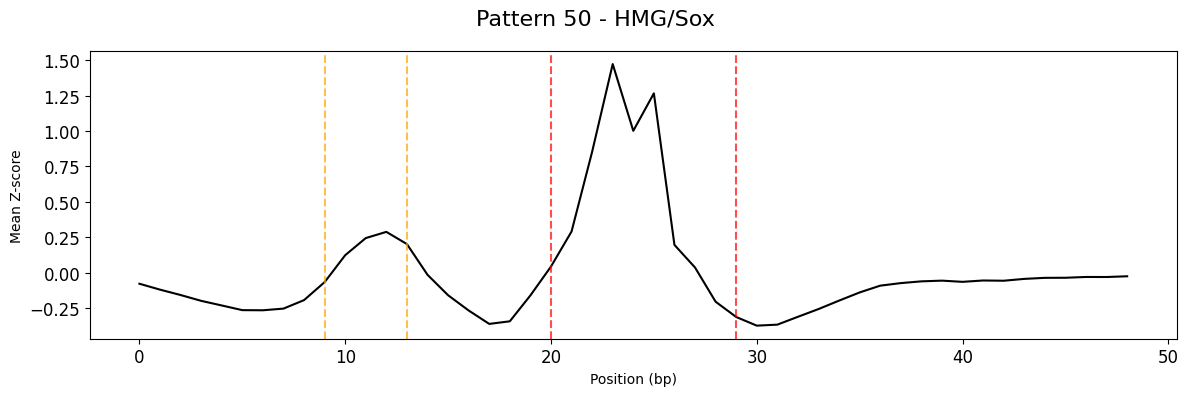

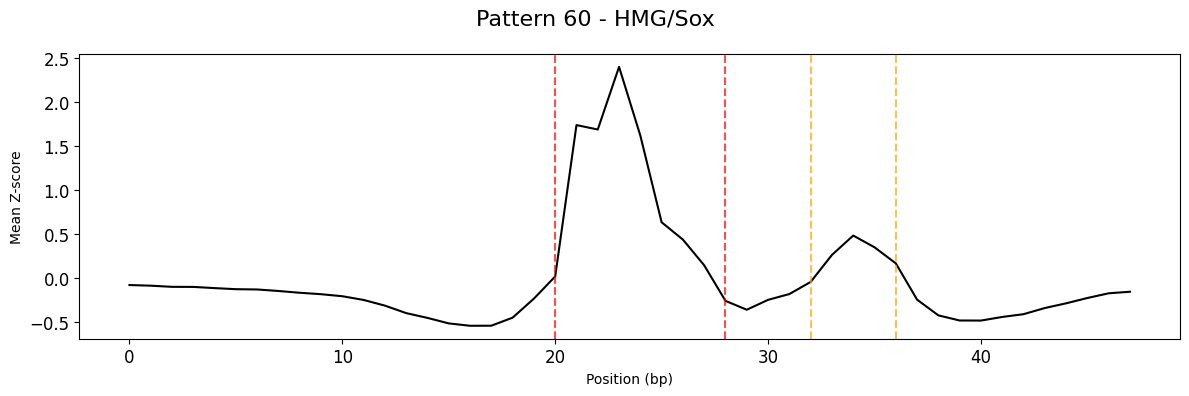

In [8]:
# Visualize both patterns with detected distance bias
for pattern_id in list(patterns_with_bias.keys()):
    result = results[pattern_id]
    tm.pl.distance_bias_profile(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", width=12, height=4)

### Heatmap Plot

The heatmap shows individual seqlet instances (rows) sorted by their maximum contribution position.  
This visualization helps identify consistent vs. variable distance bias patterns.

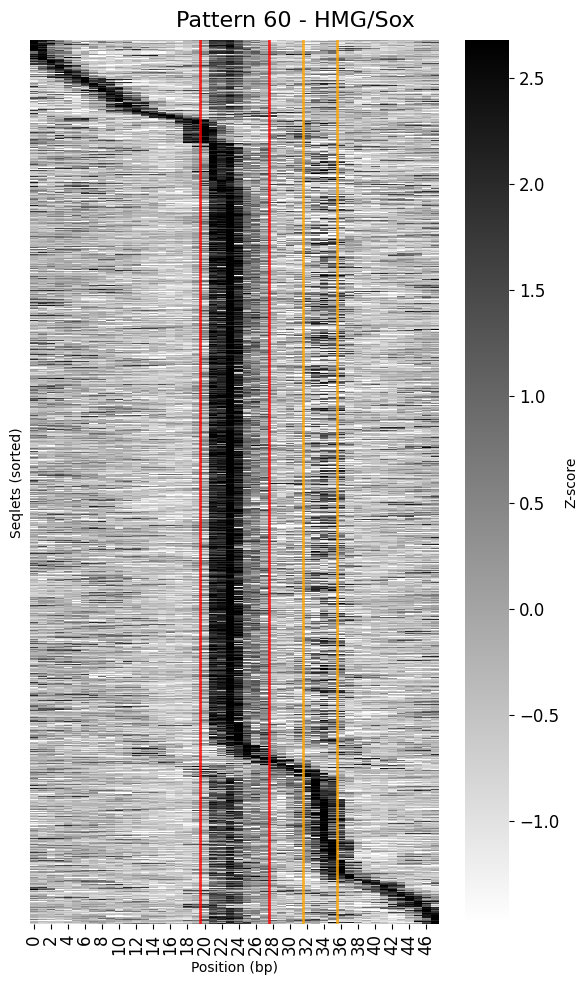

In [9]:
tm.pl.distance_bias_heatmap(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", x_label_rotation=90)

## Inspecting the biased pattern motifs

When plotting the individual pattern logo's of these two patterns that have a detected bias (one upstream, one downstream), it becomes clear that these two separate patterns should have been one combined "SOX10-dimer" pattern.  
We will fix that by extending the original seqlets and recalculating the motif similarity in a next step.  

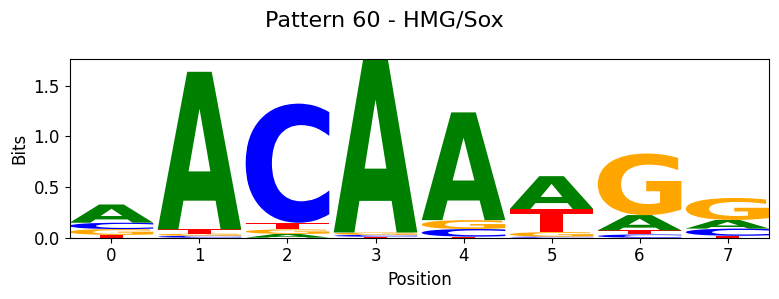

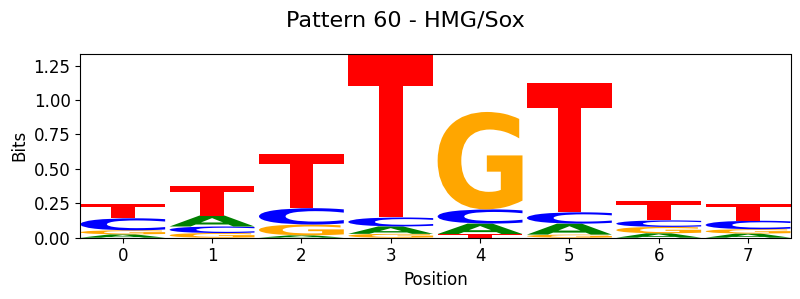

In [12]:
tm.pl.pattern_logo(
    patterns["60"],
    title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}",
    ic_threshold=0.2,
    min_nucleotides=4,
)
tm.pl.pattern_logo(
    patterns["50"],
    title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}",
    ic_threshold=0.2,
    min_nucleotides=4,
)

## Extending Seqlets to Capture Composite Motifs

Once we've identified patterns with distance bias, we can extend the seqlets to capture the full composite motif using {func}`~tfmindi.tl.extend_biased_seqlets`.

Key parameters:
- `threshold`: Z-score threshold for identifying seqlets with distance bias (default: 1.0)
- `extra_flanks`: Additional basepairs to add beyond detected peaks (default: 7bp)
- `overlap_fraction_new/old`: Overlap thresholds for removing redundant seqlets (default: 0.7)

In [13]:
# Extend seqlets for patterns showing distance bias
results_with_bias = [r for r in results.values() if r.has_bias]

new_seqlets_df, new_seqlet_matrices = tm.tl.extend_biased_seqlets(
    adata, results_with_bias, threshold=1.0, extra_flanks=3
)

Processing seqlets: 100%|██████████| 675326/675326 [00:17<00:00, 38846.95it/s]


In [15]:
# Check the results
print(f"Original number of seqlets: {len(adata.obs)}")
print(f"New number of seqlets: {len(new_seqlets_df)}")  # should be smaller (some seqlets were merged)

Original number of seqlets: 679653
New number of seqlets: 675326


## Re-clustering with Extended Seqlets

Now we can create a new AnnData object with the extended seqlets and re-run the full analysis pipeline.  
This will allow us to identify composite motif patterns that weren't captured in the initial clustering.

In [16]:
# Calculate motif similarity for extended seqlets
sim_matrix_extended = tm.pp.calculate_motif_similarity(
    new_seqlet_matrices,
    adata.var["motif_ppm"].to_dict(),
    chunk_size=50000,
    n_nearest=100,
)

Processing chunks: 100%|██████████| 14/14 [27:28<00:00, 117.78s/it]


In [17]:
# Create new AnnData with extended seqlets
adata_extended = tm.pp.create_seqlet_adata(
    sim_matrix_extended,
    new_seqlets_df,
    seqlet_matrices=new_seqlet_matrices,
    oh_sequences=adata.uns["unique_examples"]["oh"],
    contrib_scores=adata.uns["unique_examples"]["contrib"],
    motif_collection=adata.var["motif_ppm"].to_dict(),
    motif_annotations=adata.var[
        ["Direct_annot", "Motif_similarity_annot", "Orthology_annot", "Motif_similarity_and_Orthology_annot"]
    ],
    motif_to_dbd=adata.var["dbd"].to_dict(),
)

In [18]:
# Cluster the extended seqlets
tm.tl.cluster_seqlets(adata_extended, resolution=10.0)

Using CPU backend for clustering operations...
Computing PCA...
Computing neighborhood graph...


/home/VIB.LOCAL/lukas.mahieu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Computing t-SNE embedding...
Performing Leiden clustering with resolution 10.0...
Clustering complete. Found 211 clusters.
DBD annotation coverage: 675326/675326 seqlets


## Visualizing Extended Patterns

Let's create patterns from the extended seqlets and visualize them to see the captured composite motifs.

In [19]:
adata.obs["cluster_dbd"].value_counts()

cluster_dbd
C2H2 ZF             211683
Homeodomain          71022
SMAD                 59822
bZIP                 58448
bHLH                 56205
HMG/Sox              49845
MADS box             49796
E2F                  23652
Nuclear receptor     22546
Homeodomain; POU     22273
Ets                  19392
T-box                14263
Forkhead             13239
RFX                   3462
IRF                   3014
TEA                    991
Name: count, dtype: int64

In [20]:
# Create patterns from extended seqlets
patterns_extended = tm.tl.create_patterns(adata_extended, method="kmer")

Creating patterns for 211 clusters...


In [21]:
# Detect distance bias for all patterns
results = {
    k: tm.tl.detect_distance_bias(adata_extended, pattern, window=20) for k, pattern in patterns_extended.items()
}

In [22]:
# Check which patterns show a detected distance bias
patterns_with_bias_extended = {k: r for k, r in results.items() if r.has_bias}
print(f"Found {len(patterns_with_bias_extended)} patterns with distance bias out of {len(results)} total patterns")

Found 6 patterns with distance bias out of 211 total patterns


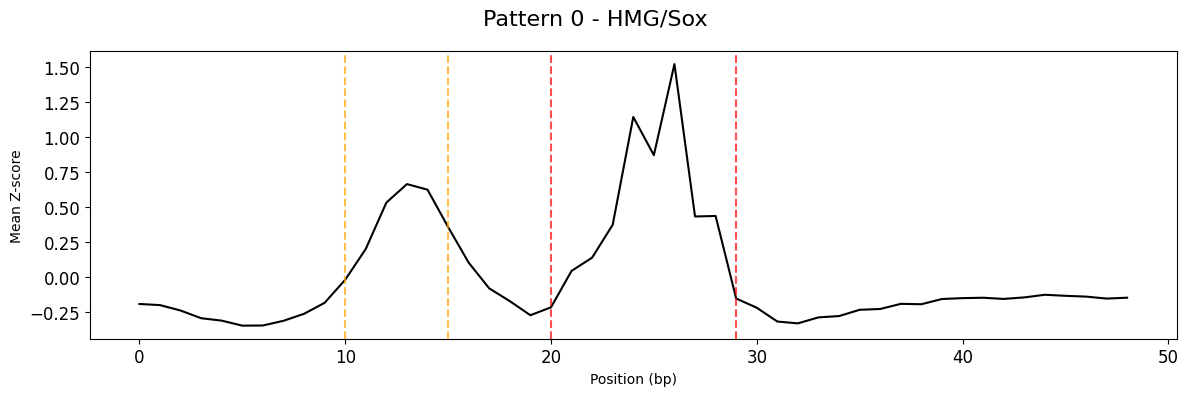

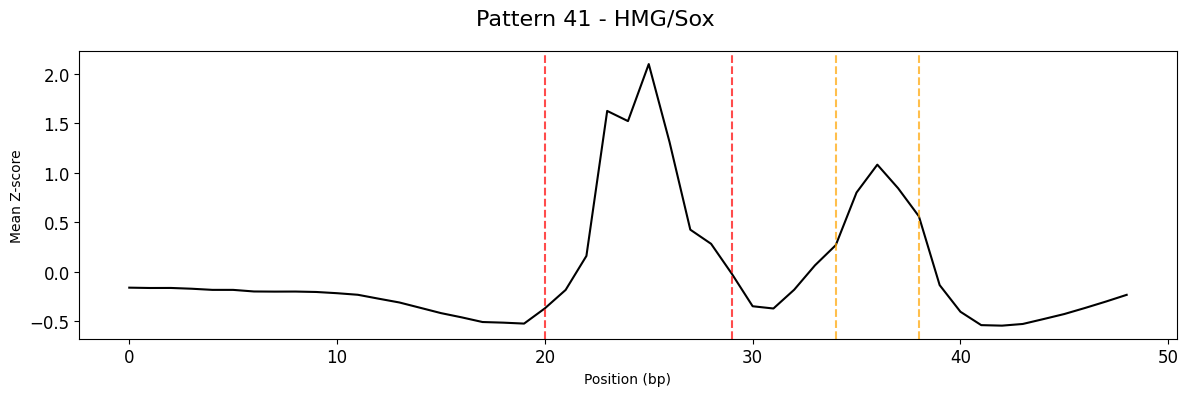

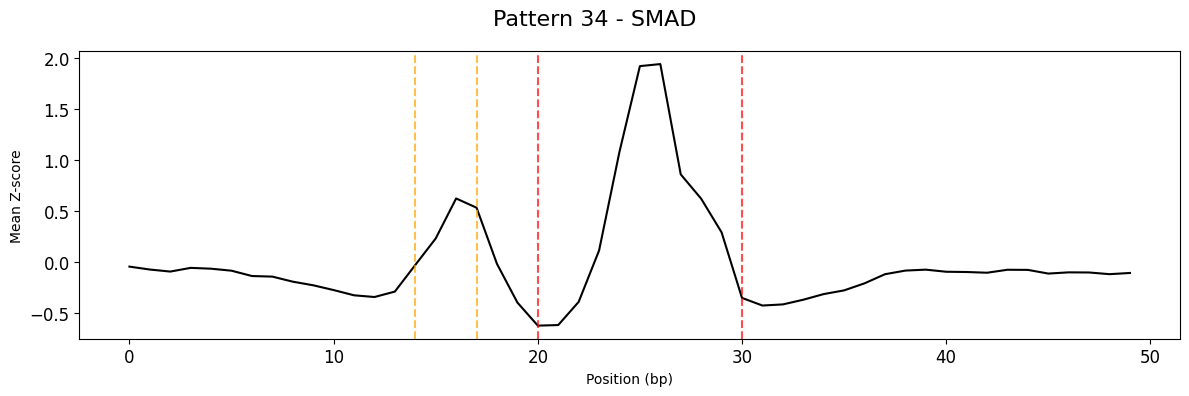

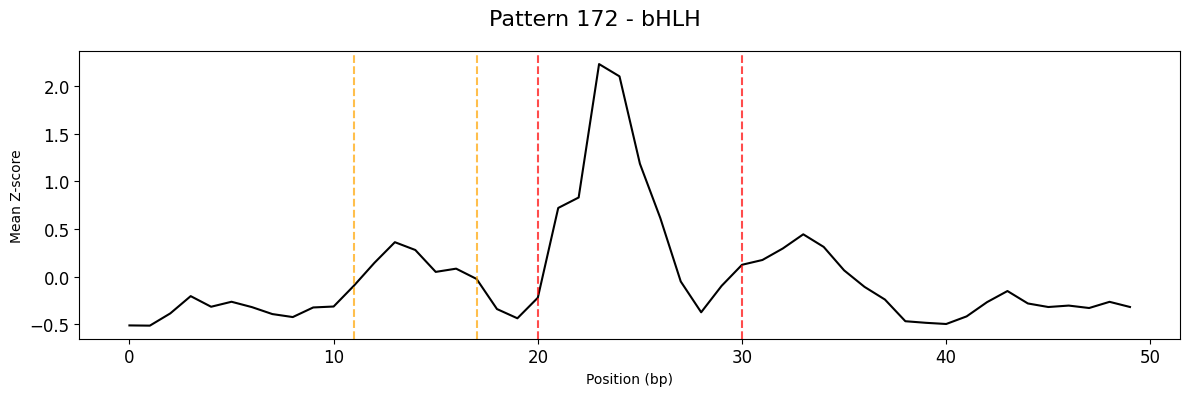

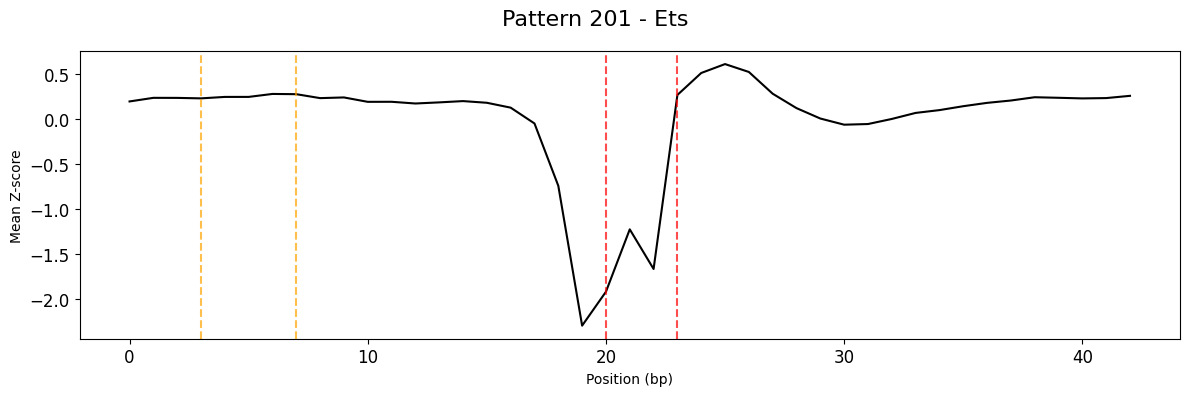

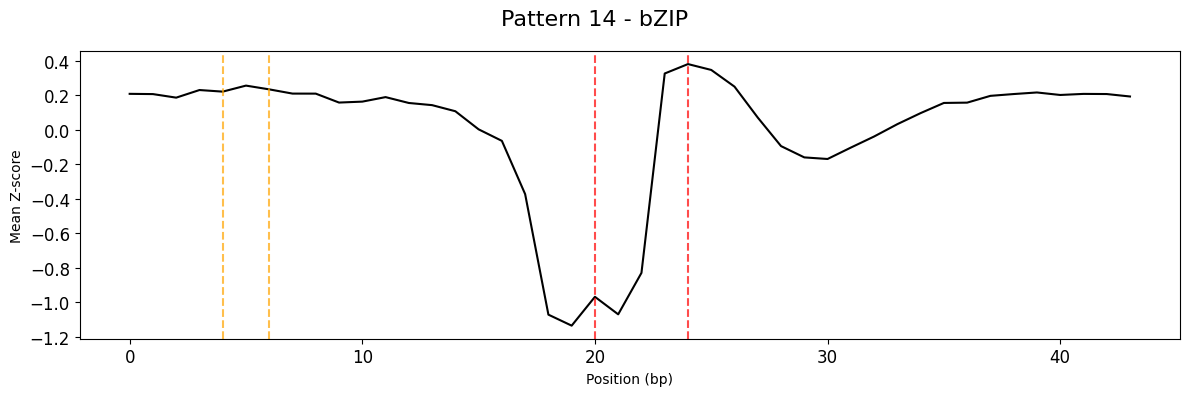

In [23]:
# Visualize both patterns with detected distance bias
for pattern_id in list(patterns_with_bias_extended.keys()):
    result = results[pattern_id]
    tm.pl.distance_bias_profile(
        result, title=f"Pattern {pattern_id} - {patterns_extended[pattern_id].dbd}", width=12, height=4
    )

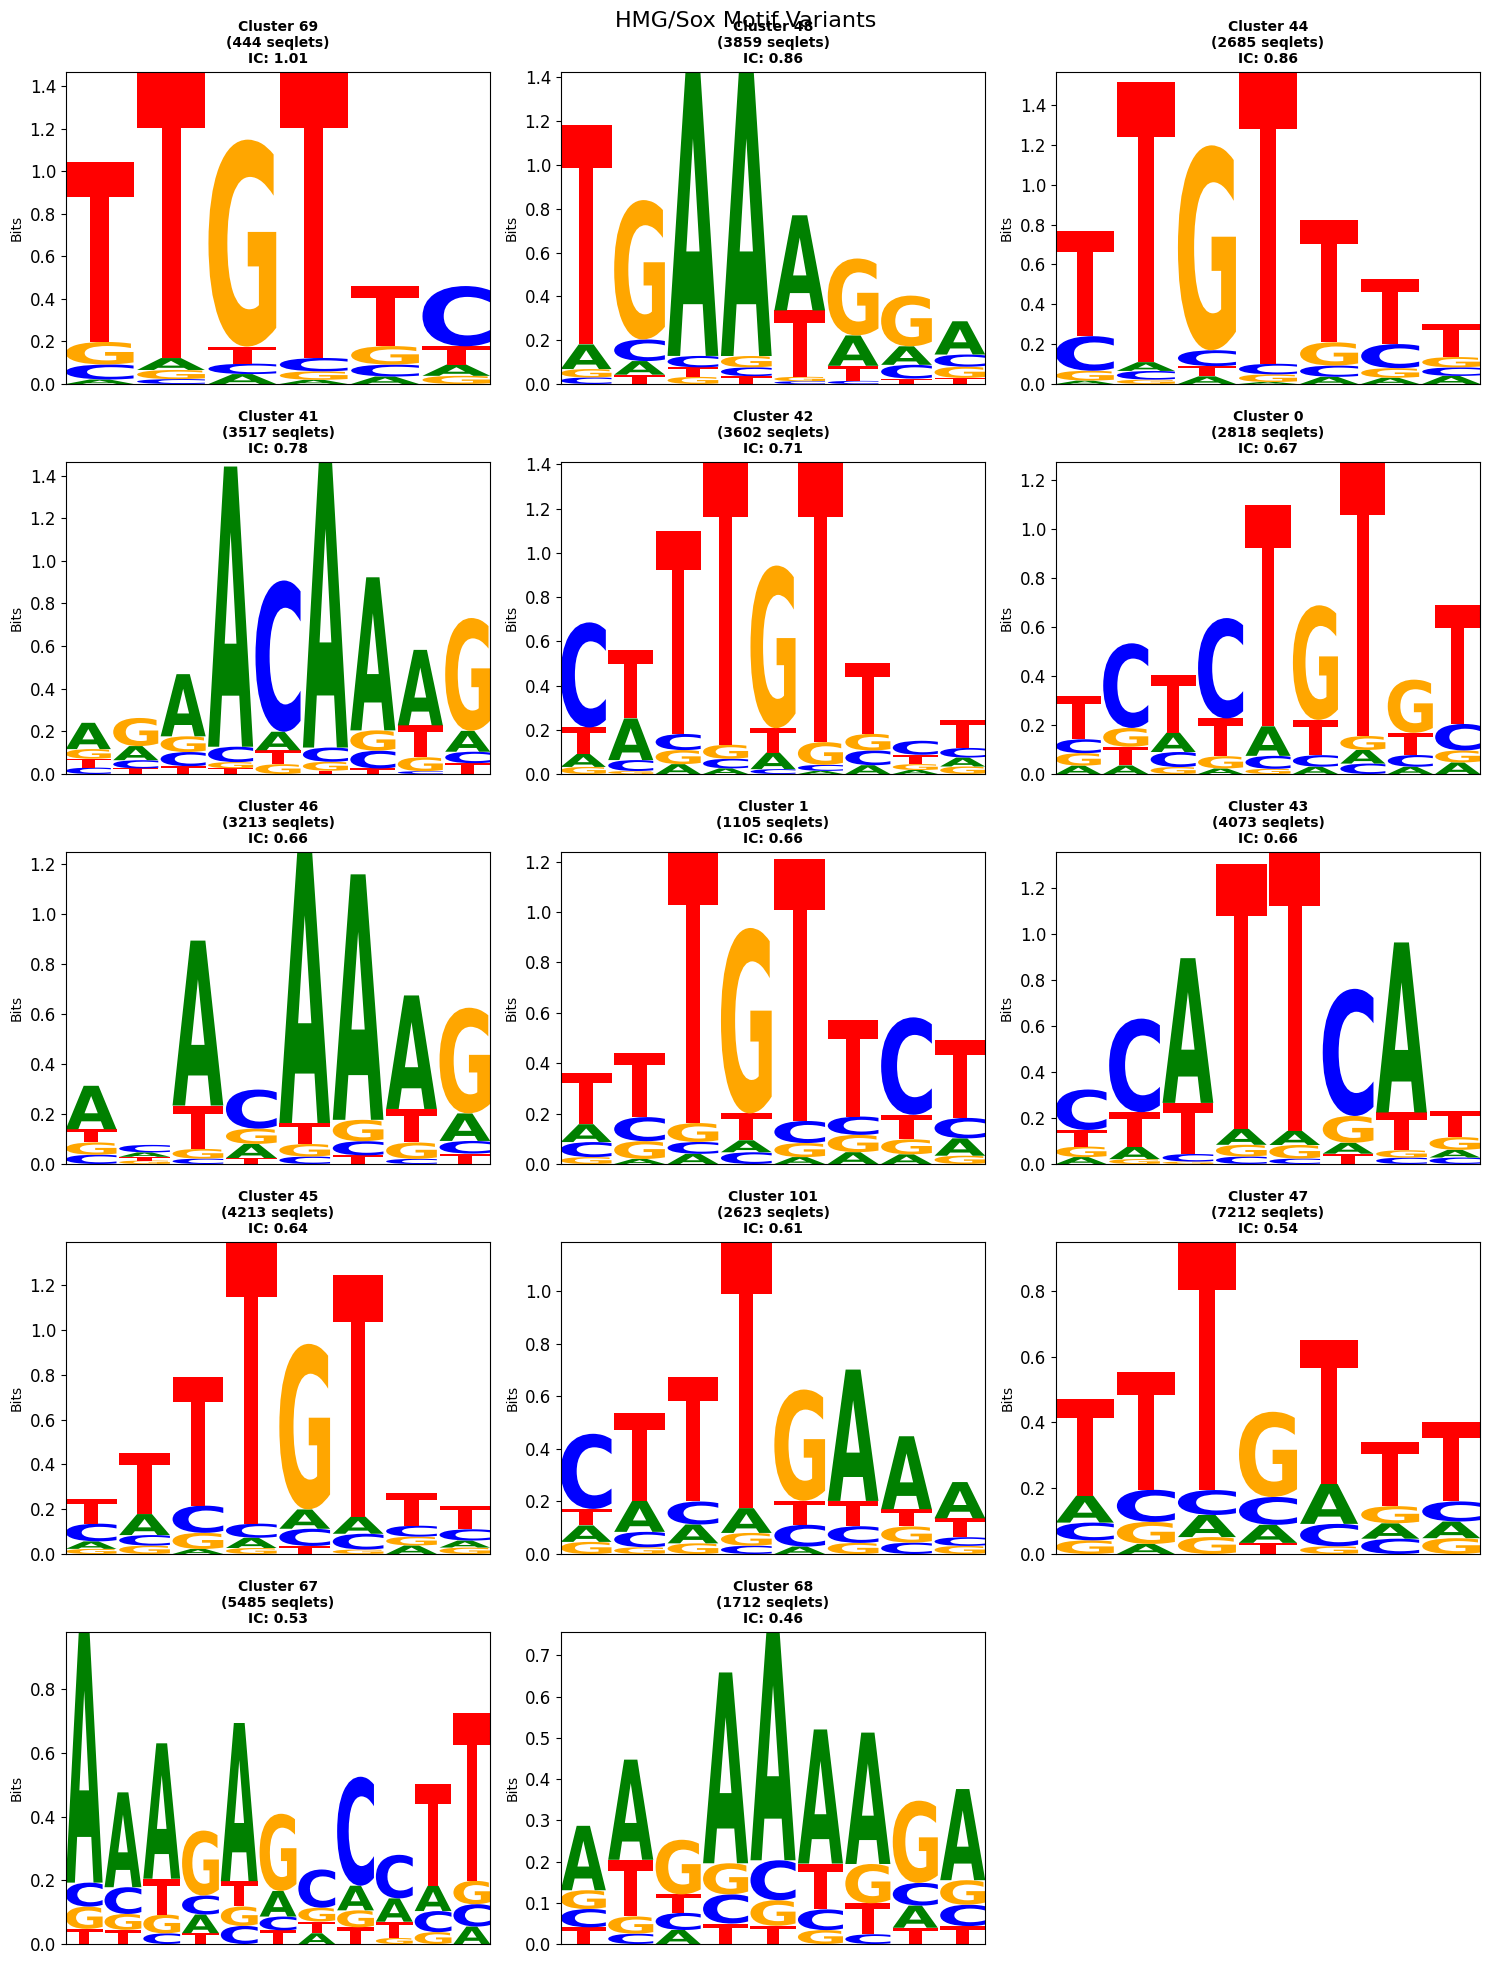

In [24]:
# Let's inspect all assigned MADS box variants
tm.pl.dbd_cluster_logos(
    patterns_extended,
    dbd_name="HMG/Sox",
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    ncols=3,
    width=15,
    height=20,
)

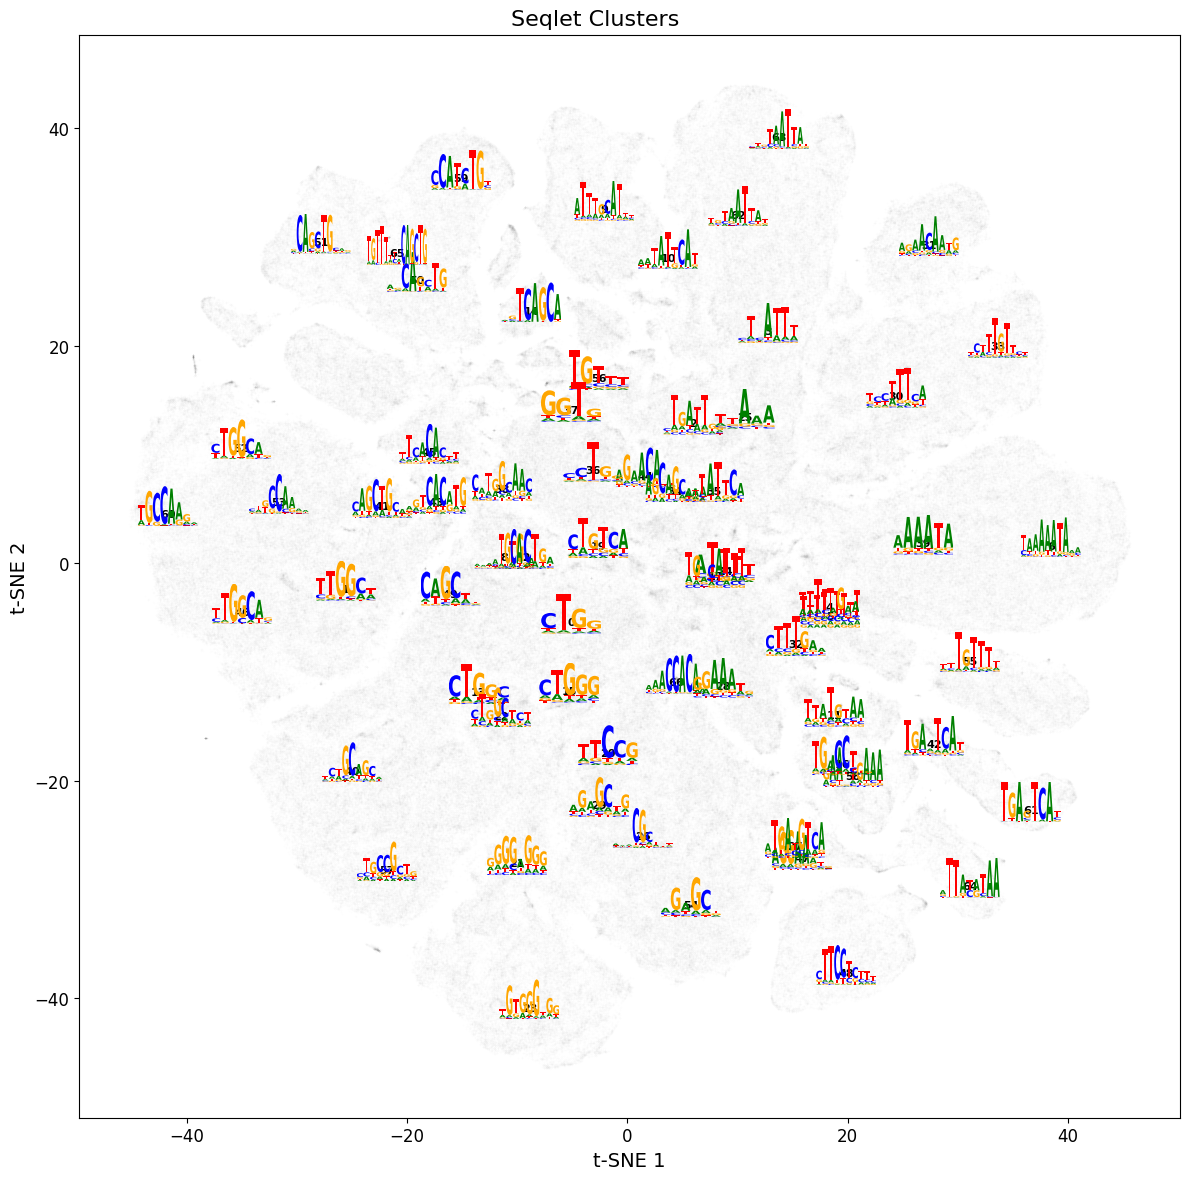

In [26]:
# Visualize extended patterns on t-SNE
tm.pl.tsne_logos(
    adata_extended,
    patterns_extended,
    gray_background=True,
    min_nucleotides=4,
    width=12,
    height=12,
    s=0.3,
    alpha=0.01,
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.1,
    min_seqlets=10,
)

In [15]:
seqlets_extended = tm.load_h5ad(DATA_DIR + "seqlets_extended_dimers.h5ad")

In [16]:
original_lengths = (adata.obs["end"] - adata.obs["start"]).describe()
extended_lengths = (seqlets_extended.obs["end"] - seqlets_extended.obs["start"]).describe()

In [17]:
original_lengths, extended_lengths

(count    679653.000000
 mean         14.965771
 std           4.337870
 min          10.000000
 25%          12.000000
 50%          14.000000
 75%          17.000000
 max          31.000000
 dtype: float64,
 count    673876.000000
 mean         15.240362
 std           4.898891
 min          10.000000
 25%          12.000000
 50%          14.000000
 75%          17.000000
 max          34.000000
 dtype: float64)

In [20]:
# Find a seqlet from pattern 60 that should have been extended
result = results["60"]
biased_seqlets = result.get_biased_seqlets(threshold=1.0)
example_seqlet = biased_seqlets[0]

print(f"Original seqlet: {example_seqlet}")
print(f"  Position: {example_seqlet.start}-{example_seqlet.end}")
print(f"  Sequence: {example_seqlet._get_consensus_sequence()}")

# Calculate what the extended version should be
ext_up, ext_down = result.extension_distances
extra_flanks = 7
if example_seqlet.is_revcomp:
    new_start = example_seqlet.start - ext_down - extra_flanks
    new_end = example_seqlet.end + ext_up + extra_flanks
else:
    new_start = example_seqlet.start - ext_up - extra_flanks
    new_end = example_seqlet.end + ext_down + extra_flanks

print(f"\nExtended should be: {new_start}-{new_end} (length={new_end - new_start})")

# Get the actual sequence from the extended region
oh = adata.uns["unique_examples"]["oh"]
extended_seq = oh[example_seqlet.example_idx, :, new_start:new_end]
extended_seq_str = "".join(["ACGT"[i] for i in extended_seq.argmax(0)])
print(f"Extended sequence: {extended_seq_str}")
print("\nDoes this look like a dimer (two monomer motifs)?")

Original seqlet: Seqlet(1047-1055(-), len=8, seq='CACAATGC', contrib=2.402)
  Position: 1047-1055
  Sequence: CACAATGC

Extended should be: 1032-1062 (length=30)
Extended sequence: CTGCCACACAAAGCTGCATTGTGGACCTTT

Does this look like a dimer (two monomer motifs)?


In [12]:
# Save extended seqlets for further analysis
tm.save_h5ad(adata_extended, DATA_DIR + "seqlets_extended_dimers.h5ad")